In [1]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  
from matplotlib.ticker import StrMethodFormatter,PercentFormatter
import seaborn as sns

# Loading Data
# dataset = load_dataset('lukebarousse/data_jobs')
# df = dataset['train'].to_pandas()

df = pd.read_csv("C:/Users/PC/Desktop/Data_Science_Project/Exporte/job_postings_flat.csv")

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [2]:
#Set Year Filter

df_2025 = df[df["job_posted_date"].dt.year==2025]

In [3]:
#Create DACH data frame and drop nan values

DACH_countries = ["Germany","Austria","Switzerland","Luxembourg"]

df_DACH = df_2025[df_2025["job_country"].isin(DACH_countries)].dropna(subset=["salary_year_avg"]).copy()

In [4]:
#Expand/Explode job skills column

df_DACH_expl = df_DACH.explode(column="job_skills")

In [5]:
#Create DF grouped by job skills column and display count of skills and median salary

df_DACH_skillset = df_DACH_expl.groupby("job_skills").agg(
    skill_count=("job_skills","count"),
    median_salary=("salary_year_avg","median")
).sort_values(by="skill_count",ascending=False)

In [6]:
#Calculate percentage of each skill being mentioned in a job posting (that mentions yearly salary)

total_job_count = len(df_DACH)

df_DACH_skillset["skill_perc"] = (df_DACH_skillset["skill_count"]/total_job_count)*100

In [7]:
#Filter DF by minimum percentage for skill prominence in job postings

skill_prom = 8

df_DACH_skills_filtered = df_DACH_skillset[df_DACH_skillset["skill_perc"]>=skill_prom]

In [8]:
#Order filtered DF by skill count in desc order

df_DACH_skills_filtered = df_DACH_skills_filtered.sort_values(by="skill_count",ascending=False)#.head(15)

df_DACH_skills_filtered = df_DACH_skills_filtered.reset_index()

In [9]:
#Additional step: One common cictionary of all skills related to a job type

df_tech = df["job_type_skills"].copy()

df_tech = df_tech.drop_duplicates()

df_tech = df_tech.dropna()

In [10]:
#Additional step: Continuation of dictionary skills by job type
##Loop through df_tech (Series) to create new dictionary (values still include duplicates)

tech_dict = {}

for row in df_tech:
    row_dict = ast.literal_eval(row)
    for k,v in row_dict.items():
        if k in tech_dict:
            tech_dict[k] += v
        else:
            tech_dict[k] = v

In [11]:
#Additional step: Continuation of dictionary skills by job type
##Loop through tech_dict to remove duplicates and return values back as lists

for k,v in tech_dict.items():
    tech_dict[k] = list(set(v))

In [12]:
#Additional step: Continuation of dictionary skills by job type
##Turn result into usable DF

df_technologies = pd.DataFrame(list(tech_dict.items()),columns=["technology","skills"])

df_technologies = df_technologies.explode("skills")


In [13]:
#Additional step: Continuation of dictionary skills by job type
##Merge exploded technologies DF with existing DF for filtered DACH skills

df_DACH_techmerge = df_DACH_skills_filtered.merge(right=df_technologies,left_on="job_skills",right_on="skills").drop("job_skills",axis=1)

df_DACH_techmerge = df_DACH_techmerge.set_index("skills")

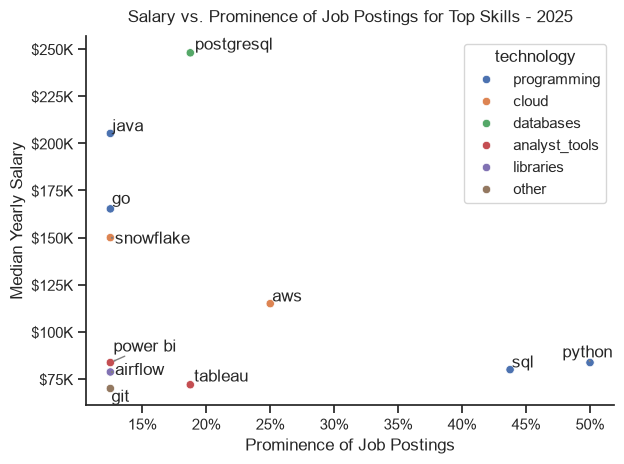

In [20]:
from adjustText import adjust_text

fig,ax = plt.subplots()

sns.scatterplot(
    data=df_DACH_techmerge,
    x="skill_perc",
    y="median_salary",
    hue="technology")

#Format displayed text for each skill in the plot
texts = []

for i,txt in enumerate(df_DACH_techmerge.index):
    texts.append(plt.text(df_DACH_techmerge["skill_perc"].iloc[i],df_DACH_techmerge["median_salary"].iloc[i],txt))

adjust_text(texts,arrowprops=dict(arrowstyle="->",color="gray"))

#Configure and clean up plot visualization
plt.xlabel("Prominence of Job Postings")
plt.ylabel("Median Yearly Salary")
plt.title("Salary vs. Prominence of Job Postings for Top Skills - 2025",pad=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_:f"${int(x/1000)}K"))
ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}%"))

sns.set_theme(style="ticks")
sns.despine()
plt.tight_layout()
plt.show()